# Check NPT
## Sanity check for NPT trajectories: structure before/after + pressure and temperature over time

In [10]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ase import units
from ase.visualize.plot import plot_atoms

from cascade.agents.db_orm import TrajectoryDB
from cascade.traj_config import load_initial_configs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
db_url = 'postgresql://ase:pw@localhost:5432/cascade'
db = TrajectoryDB(db_url)

In [3]:
runs = pd.DataFrame.from_records(db.list_runs())
# reference runs are where run_reference_dynamics.py writes NPT trajectories
reference_runs = runs[runs['run_id'].str.startswith('reference-')]
reference_runs.head()

,run_id,first_created,last_updated,n_trajectories,n_done_trajectories
0,reference-2026.07.27-20:49:59-c9a137,2026-07-27 15:50:08.264184-05:00,2026-07-27 16:25:48.186068-05:00,6,6
1,reference-2026.07.27-20:46:37-478795,2026-07-27 15:46:46.196227-05:00,2026-07-27 15:46:46.290214-05:00,6,0
2,reference-2026.07.27-20:45:25-478795,2026-07-27 15:45:51.555267-05:00,2026-07-27 15:46:04.635543-05:00,6,0
3,reference-2026.07.27-20:44:42-478795,2026-07-27 15:44:54.752524-05:00,2026-07-27 15:44:56.982845-05:00,6,0
4,reference-2026.07.27-20:37:22-daf69a,2026-07-27 15:37:30.915202-05:00,2026-07-27 15:44:03.147695-05:00,3,1


In [4]:
last_run_id = reference_runs['run_id'].iloc[0]
db.list_run_summary(last_run_id)

{'run_id': 'reference-2026.07.27-20:49:59-c9a137',
 'n_trajectories': 6,
 'n_done': 6,
 'n_active': 0,
 'total_chunks': 6,
 'total_passed_chunks': 6,
 'total_failed_chunks': 0,
 'total_pending_chunks': 0,
 'total_training_frames': 0,
 'first_created': datetime.datetime(2026, 7, 27, 15, 50, 8, 264184, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400))),
 'last_updated': datetime.datetime(2026, 7, 27, 16, 25, 48, 186068, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400)))}

In [5]:
traj_info = pd.DataFrame.from_records(db.list_trajectories_in_run(last_run_id))
traj_ids = traj_info['traj_id']
traj_info

,traj_id,target_length,chunks_completed,status,created_at,updated_at
0,0,100,0,TrajectoryStatus.COMPLETED,2026-07-27 15:50:08.274076-05:00,2026-07-27 16:24:07.283926-05:00
1,1,100,0,TrajectoryStatus.COMPLETED,2026-07-27 15:50:08.267090-05:00,2026-07-27 16:23:58.558491-05:00
2,2,100,0,TrajectoryStatus.COMPLETED,2026-07-27 15:50:08.264184-05:00,2026-07-27 16:25:48.186068-05:00
3,3,100,0,TrajectoryStatus.COMPLETED,2026-07-27 15:50:08.264913-05:00,2026-07-27 16:25:47.913243-05:00
4,4,100,0,TrajectoryStatus.COMPLETED,2026-07-27 15:50:08.273778-05:00,2026-07-27 16:18:34.424879-05:00
5,5,100,0,TrajectoryStatus.COMPLETED,2026-07-27 15:50:08.275471-05:00,2026-07-27 16:18:43.154782-05:00


In [14]:
init_configs = load_initial_configs('init_config_mof_crystalline_200_300K.json')
target_temps = {i: cfg.temperature_K for i, cfg in enumerate(init_configs)}

## First vs. last frame

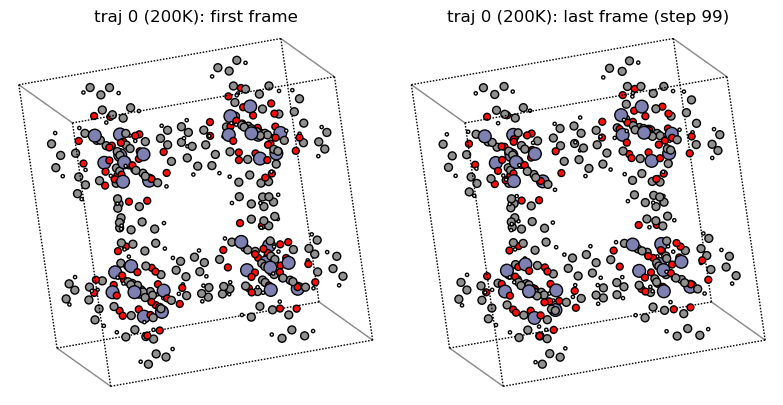

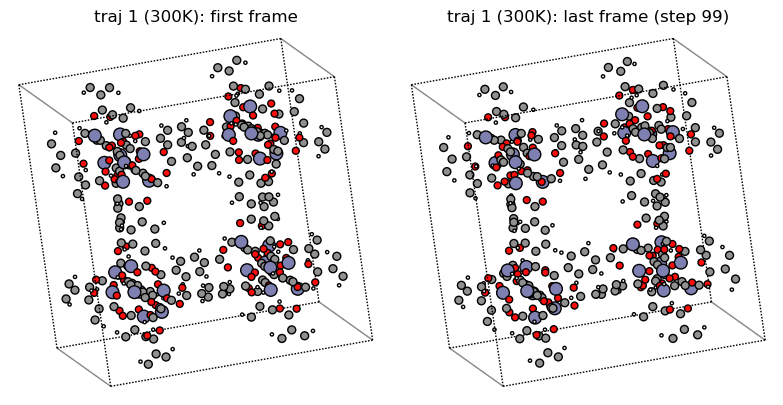

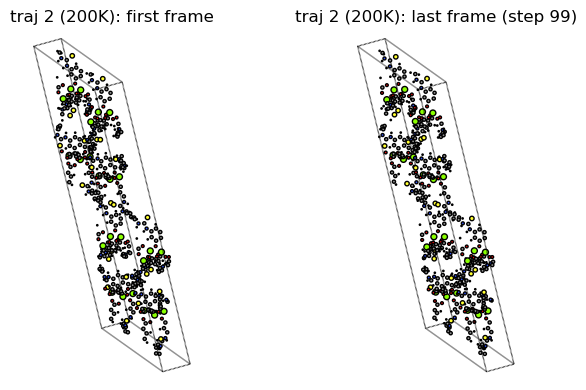

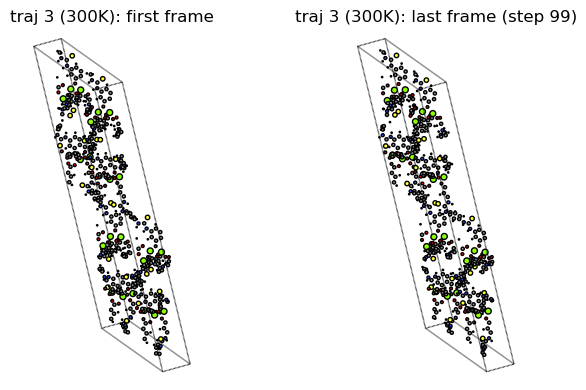

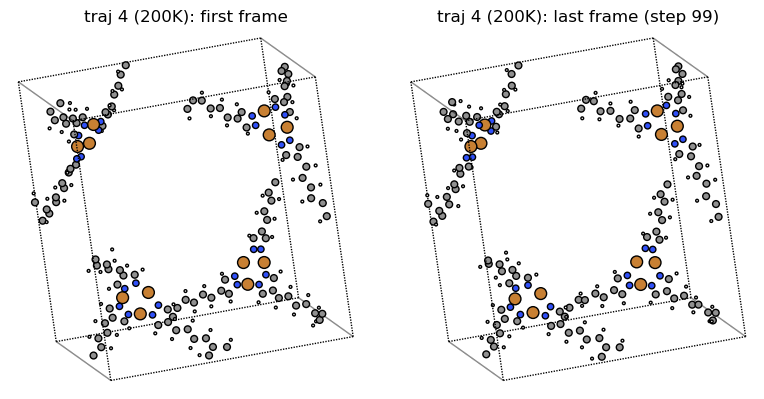

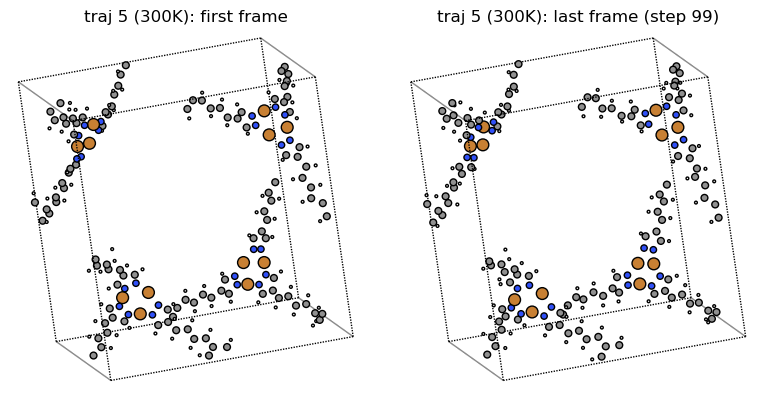

In [16]:
for traj_id in traj_ids:
    traj = db.get_trajectory_atoms(last_run_id, traj_id)
    if not traj:
        print(f'traj {traj_id}: no frames yet')
        continue

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    plot_atoms(traj[0], axes[0], radii=0.5, rotation='10x,10y,10z')
    plot_atoms(traj[-1], axes[1], radii=0.5, rotation='10x,10y,10z')
    axes[0].set_title(f'traj {traj_id} ({target_temps[traj_id]}K): first frame')
    axes[1].set_title(f'traj {traj_id} ({target_temps[traj_id]}K): last frame (step {len(traj) - 1})')

    for ax in axes:
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()

## Temperature and pressure over time

Temperature comes from the momenta ASE stores on each frame; pressure is the isotropic part of the stored stress tensor (`-trace(stress) / 3`, converted to GPa).

In [13]:
rows = []
for traj_id in traj_ids:
    traj = db.get_trajectory_atoms(last_run_id, traj_id)
    for step, atoms in enumerate(traj):
        temperature_K = atoms.get_temperature()
        stress = atoms.calc.results.get('stress') if atoms.calc is not None else None
        # stress is stored in Voigt form [xx, yy, zz, yz, xz, xy]; pressure is the
        # isotropic part, i.e. the mean of the three normal (diagonal) components
        pressure_GPa = -np.mean(stress[:3]) / units.GPa if stress is not None else np.nan
        rows.append({
            'traj_id': traj_id,
            'step': step,
            'temperature_K': temperature_K,
            'pressure_GPa': pressure_GPa,
        })
npt_df = pd.DataFrame(rows)
npt_df.head()

,traj_id,step,temperature_K,pressure_GPa
0,0,0,183.532438,0.552274
1,0,1,191.640153,0.534162
2,0,2,198.236704,0.496958
3,0,3,200.370533,0.454225
4,0,4,201.756094,0.412487


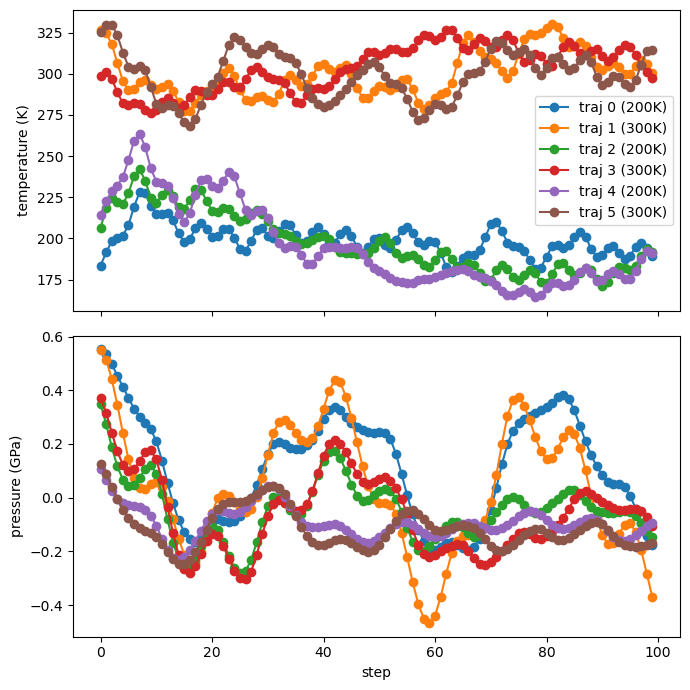

In [17]:
fig, (ax_temp, ax_press) = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
for traj_id in traj_ids:
    sub = npt_df[npt_df['traj_id'] == traj_id]
    label = f'traj {traj_id} ({target_temps[traj_id]}K)'
    ax_temp.plot(sub['step'], sub['temperature_K'], marker='o', label=label)
    ax_press.plot(sub['step'], sub['pressure_GPa'], marker='o', label=label)

ax_temp.set_ylabel('temperature (K)')
ax_press.set_ylabel('pressure (GPa)')
ax_press.set_xlabel('step')
ax_temp.legend()
plt.tight_layout()
plt.show()